# PRÁCTICA MACHINE LEARNING

## Graph Classification with Graph Neural Networks. Dataset: REDDIT-BINARY

Profesor: Francisco Escolano

Alumno: Nicolás Vives Vicente

La tarea más común para la clasificación de grafos es la **predicción de propiedades moleculares**, en la que las moléculas se representan como grafos, y la tarea puede consistir en inferir si una molécula inhibe la replicación del virus del VIH o no.

La Universidad Técnica de Dortmund ha recopilado una amplia gama de diferentes conjuntos de datos de clasificación de grafos, conocidos como [**TUDatasets**](https://chrsmrrs.github.io/datasets/), los cuales también son accesibles a través de [`torch_geometric.datasets.TUDataset`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.TUDataset) en PyTorch Geometric.

En este notebook se estudia el **conjunto de datos REDDIT-BINARY**:

## Librerías necesarias:

In [1]:
# Install PyTorch Geometric
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.0 MB/s eta 0:00:00


In [2]:
# Librerías Estándar de Python
import os
import csv
import random
from collections import Counter

# Análisis de Datos, Grafos y Visualización
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# PyTorch
import torch
import torch.nn.functional as F
from torch.nn import Linear

# PyTorch Geometric (Utilidades)
import torch_geometric.data
from torch_geometric.utils import degree
import torch_geometric.transforms as T
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx, to_dense_batch, to_dense_adj

# PyTorch Geometric (Capas GNN y Pooling)
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool  # Global Mean Pooling
from torch_geometric.nn import global_add_pool   # Global Add Pooling
from torch_geometric.nn import global_max_pool   # Global Max Pooling

# Modelo Net
from torch_geometric.nn import dense_mincut_pool, DenseGraphConv

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Inspección del dataset:

El cambio fundamental respecto a los experimentos anteriores radica en la generación de las características iniciales. Dado el enorme tamaño de estos grafos (hasta casi 4000 nodos), utilizar `OneHotDegree` habría generado vectores de una dimensionalidad computacionalmente inasumible.

Para solucionarlo, se emplea la transformación `T.LocalDegreeProfile()` de `PyTorch Geometric`. Esta técnica calcula **5 valores estadísticos** eficientes para cada nodo basándose en su vecindario local: su propio grado, así como el mínimo, máximo, media y desviación estándar de los grados de sus vecinos.

In [4]:
dataset = TUDataset(root='data/TUDataset', name='REDDIT-BINARY', transform=T.LocalDegreeProfile())

print()
print(f'Dataset: {dataset}:')
print('====================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Extraemos las etiquetas (y) de cada grafo y las contamos
labels = [data.y.item() for data in dataset]
class_counts = Counter(labels)

print('====================')
print('Samples per class:')
for cls, count in sorted(class_counts.items()):
    print(f' - Class {cls}: {count}')
print('====================')

num_nodes_list = [data.num_nodes for data in dataset]

mean_nodes = np.mean(num_nodes_list)
min_nodes = np.min(num_nodes_list)
max_nodes = np.max(num_nodes_list)

print('Node statistics per molecule:')
print(f' - Mean nodes: {mean_nodes:.2f}')
print(f' - Min nodes: {min_nodes}')
print(f' - Max nodes: {max_nodes}')
print('====================')

data = dataset[0]  # Get the first graph object.

print()
print(data)
print('=============================================================')

# Gather some statistics about the first graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Processing...
Done!



Dataset: REDDIT-BINARY(2000):
Number of graphs: 2000
Number of features: 5
Number of classes: 2
Samples per class:
 - Class 0: 1000
 - Class 1: 1000
Node statistics per molecule:
 - Mean nodes: 429.63
 - Min nodes: 6
 - Max nodes: 3782

Data(edge_index=[2, 480], y=[1], num_nodes=218, x=[218, 5])
Number of nodes: 218
Number of edges: 480
Average node degree: 2.20
Has isolated nodes: False
Has self-loops: False
Is undirected: True


* **Número total de grafos:** 2000
* **Características de nodo:** 5 (perfil de grado local sintético).
* **Número de clases:** 2 (clasificación binaria).
* **Distribución de clases:** Perfectamente equilibrada (1000 muestras para la Clase 0 y 1000 para la Clase 1).

**Estadísticas de tamaño por red (grafo):**
* **Media de nodos:** 429.63
* **Rango de nodos:** De 6 (mínimo) a 3782 (máximo).

Al analizar el primer objeto del conjunto (`Data(edge_index=[2, 480], x=[218, 5], y=[1], num_nodes=218)`), extraemos sus propiedades exactas:

* **Composición:** 218 nodos y 480 aristas, lo que resulta en un grado promedio por nodo de 2.20.
* **Etiquetas:** Una única etiqueta de clasificación para todo el grafo (`y=[1]`).

Además, el análisis topológico revela propiedades fundamentales sobre la naturaleza de estos hilos de discusión:

* **No dirigido (*Is undirected: True*):** La interacción entre dos usuarios en el hilo de la red social se modela de forma bidireccional.
* **Conectividad total (*Has isolated nodes: False*):** No existen usuarios aislados; todos forman parte activa de la estructura de discusión principal del grafo.
* **Sin bucles (*Has self-loops: False*):** No existen conexiones de un usuario consigo mismo.

Como tenemos seis clases, veamos un ejemplo de molécula perteneciente a cada una de ellas.

tensor([0])
tensor([1])


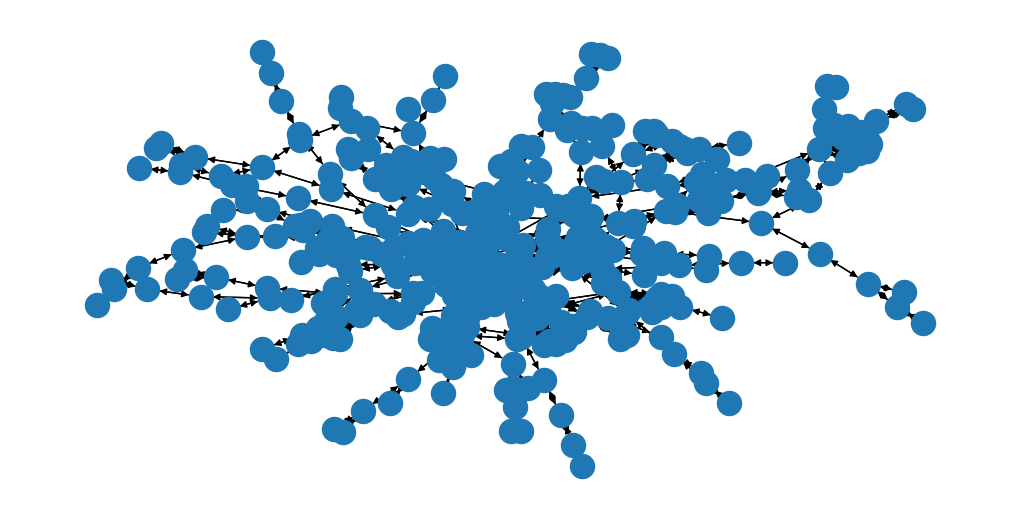

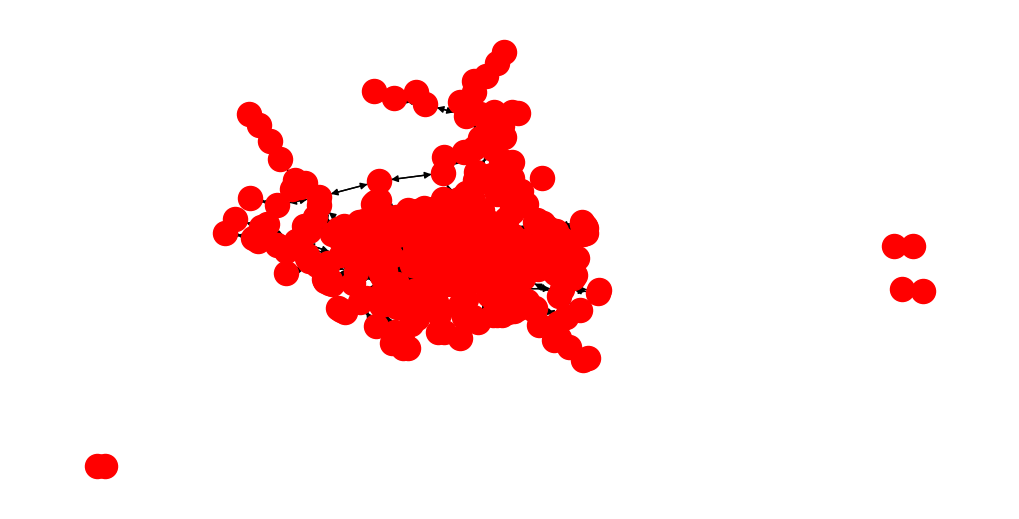

In [ ]:
data = random.choice([t for t in dataset if t.y==0])
g = to_networkx(data)
plt.figure(figsize=(10, 5))
nx.draw(g)
print(data.y)

data = random.choice([t for t in dataset if t.y==1])
g = to_networkx(data)
plt.figure(figsize=(10, 5))
nx.draw(g,node_color='r')
print(data.y)

Antes de comenzar con el entrenamiento y evaluación de los modelos conviene mencionar que se han detectado algunos problemas en el código proporcionado para la práctica y se han solucionado de las siguientes formas:

- Cálculo Aislado del Espectro Laplaciano (Graph-by-Graph):

    - Problema: Calcular el Laplaciano sobre el batch completo genera un grafo enorme, con tantas componentes desconectadas como moléculas haya en el lote. Matemáticamente, esto produce un autovalor igual a cero por cada componente. Al seleccionar los $k$ primeros, estos ceros acaparan la selección, entregando a la red autovectores vacíos que hacen inútil la geometría espacial y disparan el coste computacional al operar sobre una matriz gigante.

    - Solución implementada: Se ha aplicado una estrategia de "divide y vencerás", modificando la función para que desempaquete el lote y calcule el Laplaciano molécula por molécula de forma estrictamente individual. Esto garantiza un único autovalor cero por grafo, permitiendo que el resto de los $k$ autovectores extraigan correctamente las auténticas frecuencias estructurales y formas tridimensionales, reduciendo además la complejidad computacional.

- Corrección del Bucle de Validación (DataLoaders y Reproducibilidad):

    - Problema: La evaluación de modelos (incluyendo la red base Net) estaba consumiendo DataLoaders instanciados globalmente al inicio del notebook. Esto provocaba que, aunque los modelos variaran sus pesos iniciales y por tanto sí daban resultados distintos, no se estaba respetando la semilla de reproducibilidad para la partición de datos en las distintas iteraciones.

    - Solución implementada: Se ha reestructurado el bucle principal de evaluación. Ahora, la división del dataset y la generación de los train_loader y test_loader se ejecutan internamente en cada iteración, garantizando que los datos de entrenamiento y prueba cambien respetando la partición de los datos según la semilla activa.

Funciones heredadas con las modificaciones aplicadas:

In [5]:
def compute_laplacian_eigenvectors_pytorch(data, k):
    # 1. Convert PyTorch Geometric graph to NetworkX graph
    g = to_networkx(data, to_undirected=True)

    # 2. Compute the normalized Laplacian matrix using NetworkX
    # networkx.normalized_laplacian_matrix returns a sparse matrix
    # Then we make it dense and compatible with numpy
    L = nx.normalized_laplacian_matrix(g).todense()

    # 3. Finding eigen values and eigen vectors
    e, evecs = np.linalg.eig(L)
    #e.shape, evecs.shape

    # 4. Sort eigenvectors
    # Sort them (both e's and evecs's) ascending
    idx =e.argsort()
    e = e[idx]
    evecs = evecs[:,idx]

    # 3. Convert the sparse Laplacian matrix to a dense PyTorch tensor
    # Convert to dense numpy array first, then to torch tensor
    evecs_torch = torch.tensor(np.real(evecs[:,:k]), dtype=torch.float32)

    return evecs_torch

# Train and test functions. Use k=0 when no spectral info
def train(model, train_loader, optimizer, k):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for data in train_loader:  # Iterate in batches over the training dataset.
        optimizer.zero_grad()
        # Ensure all data components are on the correct device
        data.x = data.x.to(device)
        data.edge_index = data.edge_index.to(device)
        data.y = data.y.to(device)
        data.batch = data.batch.to(device)

        # Pass data components to the model
        out = model(data.x, data.edge_index, data.batch)

        loss = criterion(out, data.y)  # Compute the loss.
        loss.backward()  # Derive gradients.
        optimizer.step()  # Update parameters based on gradients.

        total_loss += loss.item() * data.y.size(0)
        pred = out.argmax(dim=1)
        total_correct += (pred == data.y).sum().item()
        total_samples += data.y.size(0)

    return total_loss / total_samples, total_correct / total_samples

def test(model, loader, k):
    model.eval()
    total_correct = 0
    total_samples = 0
    total_loss = 0

    with torch.no_grad():
        for data in loader:  # Iterate in batches over the training/test dataset.
            # Ensure all data components are on the correct device
            data.x = data.x.to(device)
            data.edge_index = data.edge_index.to(device)
            data.y = data.y.to(device)
            data.batch = data.batch.to(device)

            out = model(data.x, data.edge_index, data.batch)

            loss = criterion(out, data.y) # Compute the loss.
            total_loss += loss.item() * data.y.size(0)

            pred = out.argmax(dim=1)  # Use the class with highest probability.
            total_correct += int((pred == data.y).sum())  # Check against ground-truth labels.
            total_samples += data.y.size(0)

    return total_loss / total_samples, total_correct / total_samples

def split(dataset, seed):
  torch.manual_seed(seed)
  dataset = dataset.shuffle()

  # Get 25% approx per test
  split_idx = int(len(dataset) * 0.75)
  print("split idx", split_idx)

  train_dataset = dataset[:split_idx]
  test_dataset = dataset[split_idx:]

  #print(f'Number of training graphs: {len(train_dataset)}')
  #print(f'Number of test graphs: {len(test_dataset)}')
  return train_dataset, test_dataset

Debido a la cantidad de grafos y su tamaño sacamos fuera el cálculo de los autovectores, que es más eficiente computacionalmente y así agilizamos el cálculo.

In [6]:
class AñadirAutovectores(object):
    def __init__(self, k):
        self.k = k

    def __call__(self, data):
        if self.k > 0:
            # calculamos los autovectores usando la función
            evecs = compute_laplacian_eigenvectors_pytorch(data, self.k)

            # rellenamos con ceros si hay menos de k autovectores
            num_evecs = evecs.size(1)
            if num_evecs < self.k:
                columnas_faltantes = self.k - num_evecs
                evecs = F.pad(evecs, (0, columnas_faltantes, 0, 0), "constant", 0.0)

            # lo concatenamos con las características que ya tenga el grafo
            if data.x is not None:
                data.x = torch.cat([data.x, evecs], dim=1)
            else:
                data.x = evecs

        return data

Calculamos el dataset con la transformación para k=4.

In [7]:
transformacion_k = T.Compose([
    T.LocalDegreeProfile(),
    AñadirAutovectores(k=4)
])

# se calculan los autovectores y se le concatenan directamente
dataset_k = TUDataset(root='data/TUDataset', name='REDDIT-BINARY', pre_transform=transformacion_k, force_reload=True)

Processing...
Done!


## Experimento 1: Evaluación de Arquitecturas Base

Comenzamos el análisis del dataset **REDDIT-BINARY** estableciendo las líneas base. El objetivo es evaluar el comportamiento de las redes de clasificación y el impacto de la información geométrica al distinguir grandes hilos de discusión (comunidades de debate frente a preguntas y respuestas).

En este primer experimento se utilizará la configuración predeterminada del *notebook*, adaptada a las dimensiones del problema:

| Hiperparámetro | Valor |
| :--- | :--- |
| Canales Ocultos (*Hidden Channels*) | 64 |
| Número de Capas Convolucionales | 3 |
| Resolución Espectral ($k$) | 4 |
| Tipo de Agregación (*Pooling*) | Global Mean Pool |

Las redes base se han adaptado a la baja dimensionalidad de entrada de este conjunto:

* **GCN (Línea base):** Su primera capa recibe **5 dimensiones** (las estadísticas de *Local Degree Profile*). Tras 3 capas de 64 canales, finaliza en una capa lineal que emite una predicción sobre **2 clases posibles**, ignorando la topología espacial.
* **GCNEig (Fusión temprana):** Añade la codificación espectral desde el inicio. Su entrada se amplía a **9 dimensiones** (5 sintéticas + 4 espaciales), procesando simultáneamente las estadísticas del usuario y su posición global desde el primer salto de mensaje.
* **GCNEigDecoupled (Fusión tardía):** Procesa el vector de 5 estadísticas locales en la rama convolucional y la geometría espacial en una proyección lineal independiente (pasando los 4 autovectores a 32 canales). Ambas señales se concatenan en la profundidad de la red antes de emitir la predicción.

In [8]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(9, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [9]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Mean Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
  ExperimentResult = []
  best_model = None
  current_model_class = models[j]

  print(f"Training Model: {current_model_class.__name__}")

  # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
  # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

  if j == 0:
      data = dataset
  elif j > 0:
      data = dataset_k

  for i in range(10):
      print("Random State", RandList[i]," in the iteration",i)
      current_seed = RandList[i]

      train_dataset, test_dataset = split(data, current_seed)
      train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
      test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

      # Instantiate model based on its class and its required arguments
      if current_model_class == GCN:
          model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
          k_for_laplacian = 0 # GCN does not use PE
      elif current_model_class == GCNEig:
          model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
          k_for_laplacian = k_val
      elif current_model_class == GCNEigDecoupled:
          model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
          k_for_laplacian = k_val
      elif current_model_class == Net: # Net model uses in_channels, out_channels directly
          model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
          k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                              # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

      optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
      for epoch in range(1, 101):
          # The `train` function now receives the model object directly
          loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
          print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

      # The `test` function also receives the model object directly
      test_loss, acc = test(model, test_loader, k=k_for_laplacian)
      print('Test Accuracy: {:.5f}'.format(acc))

      # Save the best model over the 10 runs
      if best_model is None or acc > best_model[1]:
          best_model = [model, acc]
      ExperimentResult.append(acc)

      file_exists = os.path.isfile("resultados_REDDIT_BINARY.csv")
      with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
          writer = csv.writer(f)
          if not file_exists:
              # Escribimos las cabeceras solo la primera vez que se crea el archivo
              writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

          # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
          acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
          acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
          # Escribimos los datos específicos de esta única ejecución
          writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


  mean_acc = np.mean(ExperimentResult) * 100
  std_acc = np.std(ExperimentResult) * 100

  mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
  std_formatted = f"{std_acc:.2f}".replace('.', ',')

  with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
      writer = csv.writer(f)
      # Escribimos la línea de resumen. Las precisiones individuales van vacías.
      writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

  print(current_model_class.__name__) # Name of the model
  print('{} +- {}'.format(mean_acc, std_acc))
  global_results.append(ExperimentResult.copy())
  global_best_models.append(best_model.copy())

cuda
Training Model: GCN
Random State 12345  in the iteration 0
split idx 1500
Epoch: 001, Loss: 2.27091, Train Acc: 0.58667
Epoch: 002, Loss: 0.63041, Train Acc: 0.64733
Epoch: 003, Loss: 0.60257, Train Acc: 0.67267
Epoch: 004, Loss: 0.60191, Train Acc: 0.67467
Epoch: 005, Loss: 0.59490, Train Acc: 0.67733
Epoch: 006, Loss: 0.59410, Train Acc: 0.68933
Epoch: 007, Loss: 0.57650, Train Acc: 0.70000
Epoch: 008, Loss: 0.57141, Train Acc: 0.69067
Epoch: 009, Loss: 0.59941, Train Acc: 0.69533
Epoch: 010, Loss: 0.57673, Train Acc: 0.69600
Epoch: 011, Loss: 0.55332, Train Acc: 0.71533
Epoch: 012, Loss: 0.54839, Train Acc: 0.71067
Epoch: 013, Loss: 0.56796, Train Acc: 0.69267
Epoch: 014, Loss: 0.54861, Train Acc: 0.73133
Epoch: 015, Loss: 0.53319, Train Acc: 0.72067
Epoch: 016, Loss: 0.51297, Train Acc: 0.74533
Epoch: 017, Loss: 0.49599, Train Acc: 0.75267
Epoch: 018, Loss: 0.58913, Train Acc: 0.70067
Epoch: 019, Loss: 0.50834, Train Acc: 0.75933
Epoch: 020, Loss: 0.48442, Train Acc: 0.76067
E

Las métricas obtenidas tras la evaluación base se detallan a continuación:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 3 | Mean | 0 | 80.77 $\pm$ 3.68 | 79.90 $\pm$ 3.84 |
| **GCNEig** | 64 | 3 | Mean | 4 | 82.07 $\pm$ 2.82 | **81.88 $\pm$ 3.34** |
| **GCNEigDecoupled**| 64 | 3 | Mean | 4 | 77.74 $\pm$ 3.45 | 77.16 $\pm$ 3.92 |

El comportamiento en este conjunto difiere drásticamente de los anteriores: **apenas existe sobreajuste**. Las precisiones de entrenamiento y validación están prácticamente a la par, lo que indica un aprendizaje generalizable y robusto.

* `GCNEig` logra el mejor rendimiento (casi 82%). Al ser las características iniciales simples resúmenes estadísticos (5 valores), concatenarlas directamente con los 4 autovectores en la primera capa otorga una importancia equilibrada a la topología y a las estadísticas desde el principio.
* El rendimiento de `GCNEigDecoupled` cae al 77.16%. Aislar estas características estadísticas tan simples y retrasar la inyección geométrica resulta contraproducente en este contexto.

Aunque los resultados son positivos, usar `Global Mean Pool` en hilos de discusión tan grandes puede diluir la importancia de los usuarios clave. Esto motiva el **Experimento 2**, donde aplicaremos **`Global Max Pool`** para aislar la activación más alta.

*(Nota: Se descarta por completo evaluar `Global Add Pool`. Debido a la variabilidad extrema de tamaño —hasta 4000 nodos—, sumar las características generaría una magnitud dependiente casi en exclusiva de la cantidad de mensajes y no de la estructura del hilo, confundiendo al modelo).*

## Experimento 2: Impacto de `Global Max Pool`

En este experimento modificamos la capa de agregación (*readout layer*). Partimos de la hipótesis de que el promedio (`Mean Pool`) diluye la señal y el impacto de los usuarios clave dentro de los grandes hilos de discusión de Reddit, por lo que evaluaremos si aislar sus activaciones máximas mejora la clasificación.

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(9, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Max Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    if j == 0:
        data = dataset
    elif j > 0:
        data = dataset_k

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(data, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=data.num_features, out_channels=data.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_REDDIT_BINARY.csv")
        with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cuda
Training Model: GCN
Random State 12345  in the iteration 0
split idx 1500


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch: 001, Loss: 23.71213, Train Acc: 0.57200
Epoch: 002, Loss: 0.86184, Train Acc: 0.66400
Epoch: 003, Loss: 0.62746, Train Acc: 0.67667
Epoch: 004, Loss: 0.56931, Train Acc: 0.71333
Epoch: 005, Loss: 0.54368, Train Acc: 0.72800
Epoch: 006, Loss: 0.52923, Train Acc: 0.73333
Epoch: 007, Loss: 0.52079, Train Acc: 0.73800
Epoch: 008, Loss: 0.50501, Train Acc: 0.74867
Epoch: 009, Loss: 0.52848, Train Acc: 0.73933
Epoch: 010, Loss: 0.48981, Train Acc: 0.74867
Epoch: 011, Loss: 0.49864, Train Acc: 0.75733
Epoch: 012, Loss: 0.46231, Train Acc: 0.78200
Epoch: 013, Loss: 0.47261, Train Acc: 0.77867
Epoch: 014, Loss: 0.47851, Train Acc: 0.77467
Epoch: 015, Loss: 0.46077, Train Acc: 0.78467
Epoch: 016, Loss: 0.46770, Train Acc: 0.77467
Epoch: 017, Loss: 0.48041, Train Acc: 0.76200
Epoch: 018, Loss: 0.44269, Train Acc: 0.79600
Epoch: 019, Loss: 0.43865, Train Acc: 0.79067
Epoch: 020, Loss: 0.43634, Train Acc: 0.79600
Epoch: 021, Loss: 0.42878, Train Acc: 0.79200
Epoch: 022, Loss: 0.45776, Train 

Las métricas obtenidas tras implementar la agregación por máximos se detallan a continuación:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 3 | Max | 0 | 79.45 $\pm$ 3.25 | 78.86 $\pm$ 4.53 |
| **GCNEig** | 64 | 3 | Max | 4 | 81.19 $\pm$ 3.63 | 80.74 $\pm$ 4.01 |
| **GCNEigDec.** | 64 | 3 | Max | 4 | 81.08 $\pm$ 2.43 | **81.32 $\pm$ 3.09** |

Aplicar `Global Max Pool` altera la dinámica de las arquitecturas:

* Los modelos GCN y GCNEig experimentan una ligera caída en rendimiento respecto a la configuración con `Mean Pool`.
* GCNEigDecoupled es el gran beneficiado, pasando de un 77.16% a liderar con un **81.32%** en validación. Aislar las activaciones máximas (probablemente los usuarios clave del hilo) potencia enormemente esta arquitectura.
* Las diferencias entre *Train* y *Test* son prácticamente nulas, demostrando que las redes generalizan bien y no memorizan el conjunto de datos.

La ausencia de *overfitting* indica que el estancamiento en torno al ~81% podría deberse a un **cuello de botella en la capacidad de representación**. Al tratar con estructuras tan inmensas, 64 canales ocultos podrían quedarse cortos.

En el **Experimento 3** ajustaremos la dimensionalidad (*Hidden Channels*). Evaluaremos **128 canales** para comprobar si más memoria permite descifrar patrones más complejos, y lo contrastaremos con **32 canales** para descartar problemas de sobre-parametrización.

## Experimento 3: Ajuste de *Hidden Channels*

Para intentar superar el techo de rendimiento previo, evaluaremos el impacto de variar la capacidad latente de la red probando con **32 y 128 canales ocultos**.

Cada modelo mantendrá la capa de agregación (*readout layer*) que mejor rendimiento demostró en los experimentos anteriores:
* **GCN y GCNEig:** `Mean Pool`
* **GCNEigDecoupled:** `Max Pool`

A diferencia de los conjuntos anteriores, REDDIT-BINARY presenta un aprendizaje excepcionalmente sano y sin apenas *overfitting*. Esto nos permite plantear dos escenarios opuestos:

* **Prueba de Compresión (32 canales):** La entrada de la red consta únicamente de 5 características estadísticas simples (*Local Degree Profile*). Proyectarlas directamente sobre 64 canales podría suponer una sobre-parametrización innecesaria. Esta prueba comprobará si podemos mantener el rendimiento con un modelo más eficiente y comprimido.
* **Prueba de Capacidad (128 canales):** En el extremo opuesto, tratamos con grafos enormes que rozan los 4000 nodos. Es posible que el rendimiento actual esté estancado debido a un cuello de botella en la memoria de representación. Aumentar a 128 canales indicará si la red necesita más espacio para asimilar patrones tan grandes y complejos.

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=32,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=32, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=32, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(5, 32)
  (conv2): GCNConv(32, 32)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(9, 32)
  (conv2): GCNConv(32, 32)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(5, 32)
  (conv2): GCNConv(32, 16)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=16, bias=True)
)


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 32
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):

    if j == 0:
        POOLING_TYPE = 'Global Mean Pool'
    elif j == 1:
        POOLING_TYPE = 'Global Mean Pool'
    elif j == 2:
        POOLING_TYPE = 'Global Max Pool'

    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    if j == 0:
      data = dataset
    elif j > 0:
      data = dataset_k

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(data, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=data.num_features, out_channels=data.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_REDDIT_BINARY.csv")
        with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cuda
Training Model: GCN
Random State 12345  in the iteration 0
split idx 1500
Epoch: 001, Loss: 1.26544, Train Acc: 0.60533
Epoch: 002, Loss: 0.62190, Train Acc: 0.66867
Epoch: 003, Loss: 0.62104, Train Acc: 0.66267
Epoch: 004, Loss: 0.60101, Train Acc: 0.67400
Epoch: 005, Loss: 0.58640, Train Acc: 0.68200
Epoch: 006, Loss: 0.57312, Train Acc: 0.69600
Epoch: 007, Loss: 0.57874, Train Acc: 0.69333
Epoch: 008, Loss: 0.58650, Train Acc: 0.71333
Epoch: 009, Loss: 0.55292, Train Acc: 0.71667
Epoch: 010, Loss: 0.54286, Train Acc: 0.72200
Epoch: 011, Loss: 0.53800, Train Acc: 0.71267
Epoch: 012, Loss: 0.53780, Train Acc: 0.70600
Epoch: 013, Loss: 0.54096, Train Acc: 0.71933
Epoch: 014, Loss: 0.51587, Train Acc: 0.72267
Epoch: 015, Loss: 0.50544, Train Acc: 0.73933
Epoch: 016, Loss: 0.50017, Train Acc: 0.72600
Epoch: 017, Loss: 0.50905, Train Acc: 0.73667
Epoch: 018, Loss: 0.53404, Train Acc: 0.72267
Epoch: 019, Loss: 0.49063, Train Acc: 0.74067
Epoch: 020, Loss: 0.49008, Train Acc: 0.74200
E

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch: 001, Loss: 6.27972, Train Acc: 0.62133
Epoch: 002, Loss: 0.91785, Train Acc: 0.65267
Epoch: 003, Loss: 0.62995, Train Acc: 0.67000
Epoch: 004, Loss: 0.62763, Train Acc: 0.65333
Epoch: 005, Loss: 0.59380, Train Acc: 0.70333
Epoch: 006, Loss: 0.58747, Train Acc: 0.69733
Epoch: 007, Loss: 0.57222, Train Acc: 0.72333
Epoch: 008, Loss: 0.56930, Train Acc: 0.72133
Epoch: 009, Loss: 0.55413, Train Acc: 0.74467
Epoch: 010, Loss: 0.56752, Train Acc: 0.73200
Epoch: 011, Loss: 0.57407, Train Acc: 0.72133
Epoch: 012, Loss: 0.52851, Train Acc: 0.74133
Epoch: 013, Loss: 0.53073, Train Acc: 0.76000
Epoch: 014, Loss: 0.50990, Train Acc: 0.75933
Epoch: 015, Loss: 0.49473, Train Acc: 0.75867
Epoch: 016, Loss: 0.49596, Train Acc: 0.77133
Epoch: 017, Loss: 0.47657, Train Acc: 0.77267
Epoch: 018, Loss: 0.47850, Train Acc: 0.77267
Epoch: 019, Loss: 0.46024, Train Acc: 0.78200
Epoch: 020, Loss: 0.50000, Train Acc: 0.75533
Epoch: 021, Loss: 0.49733, Train Acc: 0.75000
Epoch: 022, Loss: 0.51102, Train A

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=128,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=128, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=128, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(5, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(9, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(5, 128)
  (conv2): GCNConv(128, 64)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=64, bias=True)
)


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 128
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):

    if j == 0:
        POOLING_TYPE = 'Global Mean Pool'
    elif j == 1:
        POOLING_TYPE = 'Global Mean Pool'
    elif j == 2:
        POOLING_TYPE = 'Global Max Pool'

    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    if j == 0:
      data = dataset
    elif j > 0:
      data = dataset_k

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(data, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=data.num_features, out_channels=data.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_REDDIT_BINARY.csv")
        with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cuda
Training Model: GCN
Random State 12345  in the iteration 0
split idx 1500
Epoch: 001, Loss: 4.61473, Train Acc: 0.56933
Epoch: 002, Loss: 0.62074, Train Acc: 0.65133
Epoch: 003, Loss: 0.59633, Train Acc: 0.66600
Epoch: 004, Loss: 0.57427, Train Acc: 0.69000
Epoch: 005, Loss: 0.53547, Train Acc: 0.72133
Epoch: 006, Loss: 0.51917, Train Acc: 0.73733
Epoch: 007, Loss: 0.53863, Train Acc: 0.73400
Epoch: 008, Loss: 0.50523, Train Acc: 0.74933
Epoch: 009, Loss: 0.48840, Train Acc: 0.74933
Epoch: 010, Loss: 0.49068, Train Acc: 0.75933
Epoch: 011, Loss: 0.47699, Train Acc: 0.74267
Epoch: 012, Loss: 0.50285, Train Acc: 0.76400
Epoch: 013, Loss: 0.47523, Train Acc: 0.76867
Epoch: 014, Loss: 0.47982, Train Acc: 0.75533
Epoch: 015, Loss: 0.47135, Train Acc: 0.76867
Epoch: 016, Loss: 0.48869, Train Acc: 0.74600
Epoch: 017, Loss: 0.46109, Train Acc: 0.76667
Epoch: 018, Loss: 0.45598, Train Acc: 0.76933
Epoch: 019, Loss: 0.46708, Train Acc: 0.76200
Epoch: 020, Loss: 0.44811, Train Acc: 0.77200
E

Las métricas obtenidas tras asfixiar y ensanchar la capacidad de las redes son las siguientes:

| Modelo | Hidden Dim. | Num. Layers | Pooling | k | Train Acc. ± Std (%) | Test Acc. ± Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Configuración: 32 canales** | | | | | | |
| **GCN** | 32 | 3 | Mean | 0 | 81.04 ± 3.44 | 80.52 ± 5.07 |
| **GCNEig** | 32 | 3 | Mean | 4 | 83.08 ± 3.44 | 77.16 ± 10.37 |
| **GCNEigDec.** | 32 | 3 | Max | 4 | 78.03 ± 1.95 | 77.82 ± 2.30 |
| **Configuración: 128 canales** | | | | | | |
| **GCN** | 128 | 3 | Mean | 0 | 81.93 ± 2.13 | 80.84 ± 2.51 |
| **GCNEig** | 128 | 3 | Mean | 4 | 79.78 ± 8.35 | 79.90 ± 7.79 |
| **GCNEigDec.** | 128 | 3 | Max | 4 | 78.33 ± 1.96 | 78.20 ± 2.81 |

Alterar la capacidad latente resulta contraproducente para las arquitecturas geométricas en este *dataset*:

* **Con 32 canales:** Los modelos espectrales se desploman por falta de espacio matemático para mapear las estructuras. `GCNEig` sufre una inestabilidad extrema (desviación superior al 10%) y `GCNEigDecoupled` cae al 77.82%.
* **Con 128 canales:** Aunque el aprendizaje sigue sano y sin memorización (Train y Test a la par), aumentar parámetros no supera las marcas logradas con 64 canales, evidenciando que el problema no es la falta de memoria por capa.

Descartamos ambas configuraciones y restauramos los **64 canales ocultos** como estándar óptimo.

El **Experimento 4** se centrará en explorar la profundidad de la red (aumentando el número de capas) para comprobar si una mayor propagación del mensaje permite romper la barrera del 81% en validación.

## Experimento 4: Profundidad de la Red (*Num. Layers*)

Tras descartar el *overfitting* y el ensanchamiento de capas, evaluaremos el impacto de la profundidad arquitectónica añadiendo una **cuarta capa convolucional** a las redes.

Se mantienen las configuraciones óptimas de agregación previas. Los modelos espectrales se ejecutarán con 64 canales, mientras que el modelo base `GCN` evaluará una combinación específica de 4 capas y 128 canales.

Pensamos que al analizar hilos de discusión que rozan los 4000 nodos, utilizar solo 3 capas puede ser insuficiente. Aumentar a 4 capas busca expandir este alcance, garantizando una propagación del mensaje mucho más profunda a través de la red.

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.conv4 = GCNConv(hidden_channels, hidden_channels) # NUEVA CAPA
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        x = x.relu() # NUEVA ACTIVACIÓN
        x = self.conv4(x, edge_index) # NUEVA CAPA

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        x = x.relu()
        x = self.conv4(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=128,seed=12345)
print(model)


class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.conv4 = GCNConv(hidden_channels, hidden_channels) # NUEVA CAPA
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        x = x.relu() # NUEVA ACTIVACIÓN
        x = self.conv4(x, edge_index) # NUEVA CAPA

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        x = x.relu()
        x = self.conv4(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)


class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.conv4 = GCNConv(hidden_channels, hidden_channels) # NUEVA CAPA
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features

        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)
        x = x.relu() # NUEVA ACTIVACIÓN
        x = self.conv4(x, edge_index) # NUEVA CAPA

        # 3. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 4. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)
        x = x.relu()
        x = self.conv4(x, edge_index)

        # 3. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(5, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (conv4): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(9, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (conv4): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (conv4): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
NUM_LAYERS = 4

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):

    if j == 0:
        POOLING_TYPE = 'Global Mean Pool'
        hidden_channels_val = 128
    elif j == 1:
        POOLING_TYPE = 'Global Mean Pool'
        hidden_channels_val = 64
    elif j == 2:
        POOLING_TYPE = 'Global Max Pool'
        hidden_channels_val = 64

    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    if j == 0:
      data = dataset
    elif j > 0:
      data = dataset_k

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(data, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=data.num_features, out_channels=data.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_REDDIT_BINARY.csv")
        with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cuda
Training Model: GCN
Random State 12345  in the iteration 0
split idx 1500
Epoch: 001, Loss: 2.69495, Train Acc: 0.59267
Epoch: 002, Loss: 0.61455, Train Acc: 0.65333
Epoch: 003, Loss: 0.57601, Train Acc: 0.68800
Epoch: 004, Loss: 0.56099, Train Acc: 0.71067
Epoch: 005, Loss: 0.54089, Train Acc: 0.72200
Epoch: 006, Loss: 0.52442, Train Acc: 0.71933
Epoch: 007, Loss: 0.52246, Train Acc: 0.72400
Epoch: 008, Loss: 0.49681, Train Acc: 0.73267
Epoch: 009, Loss: 0.47858, Train Acc: 0.75067
Epoch: 010, Loss: 0.49142, Train Acc: 0.76133
Epoch: 011, Loss: 0.45645, Train Acc: 0.76333
Epoch: 012, Loss: 0.48055, Train Acc: 0.77200
Epoch: 013, Loss: 0.57063, Train Acc: 0.71800
Epoch: 014, Loss: 0.56474, Train Acc: 0.71600
Epoch: 015, Loss: 0.54947, Train Acc: 0.72333
Epoch: 016, Loss: 0.53673, Train Acc: 0.71800
Epoch: 017, Loss: 0.53252, Train Acc: 0.71800
Epoch: 018, Loss: 0.52698, Train Acc: 0.72067
Epoch: 019, Loss: 0.51336, Train Acc: 0.73333
Epoch: 020, Loss: 0.51921, Train Acc: 0.73800
E

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch: 001, Loss: 15.70318, Train Acc: 0.59800
Epoch: 002, Loss: 0.96523, Train Acc: 0.62533
Epoch: 003, Loss: 0.65762, Train Acc: 0.61400
Epoch: 004, Loss: 0.61103, Train Acc: 0.68600
Epoch: 005, Loss: 0.60339, Train Acc: 0.71400
Epoch: 006, Loss: 0.55552, Train Acc: 0.74400
Epoch: 007, Loss: 0.51067, Train Acc: 0.74267
Epoch: 008, Loss: 0.49760, Train Acc: 0.74333
Epoch: 009, Loss: 0.49181, Train Acc: 0.75000
Epoch: 010, Loss: 0.51448, Train Acc: 0.73133
Epoch: 011, Loss: 0.47462, Train Acc: 0.74600
Epoch: 012, Loss: 0.48481, Train Acc: 0.74400
Epoch: 013, Loss: 0.48403, Train Acc: 0.73733
Epoch: 014, Loss: 0.47407, Train Acc: 0.75333
Epoch: 015, Loss: 0.53758, Train Acc: 0.75800
Epoch: 016, Loss: 0.47846, Train Acc: 0.76533
Epoch: 017, Loss: 0.48345, Train Acc: 0.75600
Epoch: 018, Loss: 0.47836, Train Acc: 0.75400
Epoch: 019, Loss: 0.45950, Train Acc: 0.76600
Epoch: 020, Loss: 0.46070, Train Acc: 0.77267
Epoch: 021, Loss: 0.46769, Train Acc: 0.77733
Epoch: 022, Loss: 0.45208, Train 

Las métricas obtenidas tras aumentar la profundidad a 4 capas confirman nuestra hipótesis:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 128 | 4 | Mean | 0 | 78.91 $\pm$ 5.68 | 77.48 $\pm$ 6.13 |
| **GCNEig** | 64 | 4 | Mean | 4 | 84.61 $\pm$ 2.14 | 82.10 $\pm$ 2.69 |
| **GCNEigDec.** | 64 | 4 | Max | 4 | 83.18 $\pm$ 2.30 | **82.46 $\pm$ 3.25** |

* Los modelos geométricos experimentan un salto de calidad notable. `GCNEigDecoupled` logra un excelente **82.46%** en validación, seguido de cerca por `GCNEig` (82.10%).
* El *overfitting* sigue controlado (precisiones de entrenamiento en torno al 83-84%). La red utiliza esta cuarta capa para generalizar mejor las estructuras, no para memorizarlas.
* Al aumentar la profundidad y la anchura careciendo de información geométrica, el rendimiento del modelo `GCN` cae al 77.48% con gran inestabilidad. Esto es síntoma de ***oversmoothing***, los vectores de los nodos acaban promediándose tras 4 saltos hasta volverse indistinguibles, destruyendo la capacidad predictiva.

A la vista de estos excelentes resultados, establecemos las **4 capas convolucionales y 64 canales** como la estructura definitiva para nuestros modelos espectrales en este conjunto de datos.

El **Experimento 5** se centrará en la capa de entrada. Variaremos el número de autovectores del Laplaciano ($k \in \{6, 8, 10\}$) para comprobar si proporcionar una mayor resolución espacial de la topología ayuda a la red a perfeccionar aún más su capacidad predictiva en grafos tan inmensos.

## Experimento 5: *Positional Encoding* ($k$)

Para finalizar la experimentación, y habiendo fijado la profundidad en 4 capas y 64 *hidden channels* con la capa de agregación óptima para cada modelo, procedemos a evaluar cómo afecta el aumento de la resolución espacial mediante la variación del número de autovectores del Laplaciano ($k$). Incrementamos el parámetro a $k=6$, $k=8$ y $k=10$ para comprobar si proporcionar mayor información de la topología ayuda a la red a clasificar mejor.

Al tratar con hilos de Reddit que alcanzan casi los 4000 usuarios, una resolución de $k=4$ nos proporciona una buena visión general de la estructura, pero podría quedarse corta para identificar pequeñas comunidades muy interconectadas. Incrementar el parámetro a $k=6, 8, 10$ busca dotar a la red de coordenadas espaciales con mayor densidad de información estructural. En teoría, al haber expandido el campo receptor a 4 capas, la red ahora debería ser capaz de asimilar y propagar estas frecuencias más altas para distinguir con mayor precisión si el hilo pertenece a una comunidad de debate o a una de preguntas y respuestas.

In [ ]:
transformacion_k = T.Compose([
    T.LocalDegreeProfile(),
    AñadirAutovectores(k=6)
])

# se calculan los autovectores y se le concatenan directamente
dataset_k = TUDataset(root='data/TUDataset', name='REDDIT-BINARY', pre_transform=transformacion_k, force_reload=True)

Processing...
Done!


In [ ]:
class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.conv4 = GCNConv(hidden_channels, hidden_channels) # NUEVA CAPA
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        x = x.relu() # NUEVA ACTIVACIÓN
        x = self.conv4(x, edge_index) # NUEVA CAPA

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        x = x.relu()
        x = self.conv4(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=6)
print(model)


class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.conv4 = GCNConv(hidden_channels, hidden_channels) # NUEVA CAPA
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features

        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)
        x = x.relu() # NUEVA ACTIVACIÓN
        x = self.conv4(x, edge_index) # NUEVA CAPA

        # 3. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 4. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)
        x = x.relu()
        x = self.conv4(x, edge_index)

        # 3. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=6)
print(model)

GCNEig(
  (conv1): GCNConv(11, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (conv4): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (conv4): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
  (lin2): Linear(in_features=6, out_features=32, bias=True)
)


#### *k = 6*

In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 6

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
NUM_LAYERS = 4

# Here you can add models to train and test (include your own models)
models = [GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

data = dataset_k

for j in range(len(models)):
    if j == 0:
        POOLING_TYPE = 'Global Mean Pool'
    elif j == 1:
        POOLING_TYPE = 'Global Max Pool'

    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(data, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=data.num_features, out_channels=data.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_REDDIT_BINARY.csv")
        with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cuda
Training Model: GCNEig
Random State 12345  in the iteration 0
split idx 1500
Epoch: 001, Loss: 1.08740, Train Acc: 0.59600
Epoch: 002, Loss: 0.63651, Train Acc: 0.67200
Epoch: 003, Loss: 0.64058, Train Acc: 0.63733
Epoch: 004, Loss: 0.58615, Train Acc: 0.69600
Epoch: 005, Loss: 0.57159, Train Acc: 0.68467
Epoch: 006, Loss: 0.55862, Train Acc: 0.70400
Epoch: 007, Loss: 0.53171, Train Acc: 0.72667
Epoch: 008, Loss: 0.51775, Train Acc: 0.73133
Epoch: 009, Loss: 0.52471, Train Acc: 0.71200
Epoch: 010, Loss: 0.50605, Train Acc: 0.72333
Epoch: 011, Loss: 0.48450, Train Acc: 0.73933
Epoch: 012, Loss: 0.49470, Train Acc: 0.74400
Epoch: 013, Loss: 0.48501, Train Acc: 0.74467
Epoch: 014, Loss: 0.48114, Train Acc: 0.74533
Epoch: 015, Loss: 0.46171, Train Acc: 0.75533
Epoch: 016, Loss: 0.46124, Train Acc: 0.76533
Epoch: 017, Loss: 0.44550, Train Acc: 0.77867
Epoch: 018, Loss: 0.46021, Train Acc: 0.76933
Epoch: 019, Loss: 0.49344, Train Acc: 0.76133
Epoch: 020, Loss: 0.45275, Train Acc: 0.7853

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch: 001, Loss: 7.49650, Train Acc: 0.59867
Epoch: 002, Loss: 1.34231, Train Acc: 0.65333
Epoch: 003, Loss: 0.62929, Train Acc: 0.63400
Epoch: 004, Loss: 0.59658, Train Acc: 0.69000
Epoch: 005, Loss: 0.55355, Train Acc: 0.72200
Epoch: 006, Loss: 0.51585, Train Acc: 0.74200
Epoch: 007, Loss: 0.51341, Train Acc: 0.75000
Epoch: 008, Loss: 0.53240, Train Acc: 0.73400
Epoch: 009, Loss: 0.51088, Train Acc: 0.74400
Epoch: 010, Loss: 0.49497, Train Acc: 0.75800
Epoch: 011, Loss: 0.48359, Train Acc: 0.75000
Epoch: 012, Loss: 0.47525, Train Acc: 0.77067
Epoch: 013, Loss: 0.46246, Train Acc: 0.77400
Epoch: 014, Loss: 0.44532, Train Acc: 0.77800
Epoch: 015, Loss: 0.42420, Train Acc: 0.79533
Epoch: 016, Loss: 0.42524, Train Acc: 0.79200
Epoch: 017, Loss: 0.47374, Train Acc: 0.76533
Epoch: 018, Loss: 0.47074, Train Acc: 0.76467
Epoch: 019, Loss: 0.44904, Train Acc: 0.78533
Epoch: 020, Loss: 0.42851, Train Acc: 0.79200
Epoch: 021, Loss: 0.42826, Train Acc: 0.78000
Epoch: 022, Loss: 0.39870, Train A

#### *k = 8*

In [ ]:
transformacion_k = T.Compose([
    T.LocalDegreeProfile(),
    AñadirAutovectores(k=8)
])

# se calculan los autovectores y se le concatenan directamente
dataset_k = TUDataset(root='data/TUDataset', name='REDDIT-BINARY', pre_transform=transformacion_k, force_reload=True)

Processing...
Done!


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 8

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
NUM_LAYERS = 4

# Here you can add models to train and test (include your own models)
models = [GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

data = dataset_k

for j in range(len(models)):
    if j == 0:
        POOLING_TYPE = 'Global Mean Pool'
    elif j == 1:
        POOLING_TYPE = 'Global Max Pool'

    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(data, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=data.num_features, out_channels=data.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_REDDIT_BINARY.csv")
        with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cuda
Training Model: GCNEig
Random State 12345  in the iteration 0
split idx 1500
Epoch: 001, Loss: 1.69995, Train Acc: 0.59133
Epoch: 002, Loss: 0.62765, Train Acc: 0.63933
Epoch: 003, Loss: 0.58330, Train Acc: 0.68000
Epoch: 004, Loss: 0.57071, Train Acc: 0.68333
Epoch: 005, Loss: 0.54610, Train Acc: 0.72400
Epoch: 006, Loss: 0.54661, Train Acc: 0.72400
Epoch: 007, Loss: 0.52929, Train Acc: 0.72400
Epoch: 008, Loss: 0.51722, Train Acc: 0.72533
Epoch: 009, Loss: 0.50218, Train Acc: 0.73733
Epoch: 010, Loss: 0.52053, Train Acc: 0.73200
Epoch: 011, Loss: 0.50530, Train Acc: 0.73400
Epoch: 012, Loss: 0.49516, Train Acc: 0.74267
Epoch: 013, Loss: 0.48787, Train Acc: 0.75267
Epoch: 014, Loss: 0.49170, Train Acc: 0.73933
Epoch: 015, Loss: 0.49683, Train Acc: 0.74333
Epoch: 016, Loss: 0.54000, Train Acc: 0.73467
Epoch: 017, Loss: 0.49568, Train Acc: 0.74000
Epoch: 018, Loss: 0.47862, Train Acc: 0.75867
Epoch: 019, Loss: 0.45612, Train Acc: 0.76800
Epoch: 020, Loss: 0.45692, Train Acc: 0.7773

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch: 001, Loss: 6.92230, Train Acc: 0.59533
Epoch: 002, Loss: 1.37475, Train Acc: 0.66133
Epoch: 003, Loss: 0.80392, Train Acc: 0.62467
Epoch: 004, Loss: 0.58321, Train Acc: 0.65133
Epoch: 005, Loss: 0.54491, Train Acc: 0.71867
Epoch: 006, Loss: 0.51371, Train Acc: 0.73867
Epoch: 007, Loss: 0.49739, Train Acc: 0.73733
Epoch: 008, Loss: 0.48700, Train Acc: 0.75933
Epoch: 009, Loss: 0.50416, Train Acc: 0.72933
Epoch: 010, Loss: 0.46473, Train Acc: 0.75600
Epoch: 011, Loss: 0.44837, Train Acc: 0.76600
Epoch: 012, Loss: 0.44568, Train Acc: 0.78400
Epoch: 013, Loss: 0.44381, Train Acc: 0.78000
Epoch: 014, Loss: 0.43975, Train Acc: 0.78400
Epoch: 015, Loss: 0.42962, Train Acc: 0.78933
Epoch: 016, Loss: 0.41462, Train Acc: 0.80200
Epoch: 017, Loss: 0.45665, Train Acc: 0.76800
Epoch: 018, Loss: 0.44661, Train Acc: 0.78133
Epoch: 019, Loss: 0.41320, Train Acc: 0.79267
Epoch: 020, Loss: 0.41005, Train Acc: 0.80867
Epoch: 021, Loss: 0.40828, Train Acc: 0.80067
Epoch: 022, Loss: 0.41876, Train A

#### *k = 10*

In [ ]:
transformacion_k = T.Compose([
    T.LocalDegreeProfile(),
    AñadirAutovectores(k=10)
])

# se calculan los autovectores y se le concatenan directamente
dataset_k = TUDataset(root='data/TUDataset', name='REDDIT-BINARY', pre_transform=transformacion_k, force_reload=True)

Processing...
Done!


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 10

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
NUM_LAYERS = 4

# Here you can add models to train and test (include your own models)
models = [GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

data = dataset_k

for j in range(len(models)):
    if j == 0:
        POOLING_TYPE = 'Global Mean Pool'
    elif j == 1:
        POOLING_TYPE = 'Global Max Pool'

    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(data, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=data.num_features, out_channels=data.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_REDDIT_BINARY.csv")
        with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cuda
Training Model: GCNEig
Random State 12345  in the iteration 0
split idx 1500
Epoch: 001, Loss: 1.36356, Train Acc: 0.58200
Epoch: 002, Loss: 0.61172, Train Acc: 0.65800
Epoch: 003, Loss: 0.59775, Train Acc: 0.67333
Epoch: 004, Loss: 0.58300, Train Acc: 0.68000
Epoch: 005, Loss: 0.54358, Train Acc: 0.71400
Epoch: 006, Loss: 0.50624, Train Acc: 0.73333
Epoch: 007, Loss: 0.49278, Train Acc: 0.75067
Epoch: 008, Loss: 0.52491, Train Acc: 0.72867
Epoch: 009, Loss: 0.50117, Train Acc: 0.74800
Epoch: 010, Loss: 0.48285, Train Acc: 0.74067
Epoch: 011, Loss: 0.47549, Train Acc: 0.77000
Epoch: 012, Loss: 0.48713, Train Acc: 0.76600
Epoch: 013, Loss: 0.49065, Train Acc: 0.74600
Epoch: 014, Loss: 0.48681, Train Acc: 0.74933
Epoch: 015, Loss: 0.46372, Train Acc: 0.76267
Epoch: 016, Loss: 0.47235, Train Acc: 0.75400
Epoch: 017, Loss: 0.43754, Train Acc: 0.77533
Epoch: 018, Loss: 0.45990, Train Acc: 0.77600
Epoch: 019, Loss: 0.45918, Train Acc: 0.78400
Epoch: 020, Loss: 0.44142, Train Acc: 0.7773

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch: 001, Loss: 13.32240, Train Acc: 0.59800
Epoch: 002, Loss: 1.22535, Train Acc: 0.64867
Epoch: 003, Loss: 0.58591, Train Acc: 0.70067
Epoch: 004, Loss: 0.56511, Train Acc: 0.68533
Epoch: 005, Loss: 0.51222, Train Acc: 0.72667
Epoch: 006, Loss: 0.49144, Train Acc: 0.73600
Epoch: 007, Loss: 0.45350, Train Acc: 0.77333
Epoch: 008, Loss: 0.46702, Train Acc: 0.73400
Epoch: 009, Loss: 0.43610, Train Acc: 0.76200
Epoch: 010, Loss: 0.44908, Train Acc: 0.76600
Epoch: 011, Loss: 0.44972, Train Acc: 0.74533
Epoch: 012, Loss: 0.45023, Train Acc: 0.74867
Epoch: 013, Loss: 0.44723, Train Acc: 0.76200
Epoch: 014, Loss: 0.55749, Train Acc: 0.74533
Epoch: 015, Loss: 0.51109, Train Acc: 0.73267
Epoch: 016, Loss: 0.44558, Train Acc: 0.76533
Epoch: 017, Loss: 0.41501, Train Acc: 0.77067
Epoch: 018, Loss: 0.53034, Train Acc: 0.70800
Epoch: 019, Loss: 0.51579, Train Acc: 0.75667
Epoch: 020, Loss: 0.49147, Train Acc: 0.75200
Epoch: 021, Loss: 0.46667, Train Acc: 0.76400
Epoch: 022, Loss: 0.44782, Train 

Las métricas obtenidas tras aumentar la resolución espectral se presentan en la siguiente tabla. Se omite el modelo base `GCN` ya que no hace uso de este hiperparámetro.

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Resolución $k = 6$** | | | | | | |
| **GCNEig** | 64 | 4 | Mean | 6 | 82.81 $\pm$ 4.20 | 79.98 $\pm$ 4.83 |
| **GCNEigDec.** | 64 | 4 | Max | 6 | 84.69 $\pm$ 2.06 | **83.14 $\pm$ 2.38** |
| **Resolución $k = 8$** | | | | | | |
| **GCNEig** | 64 | 4 | Mean | 8 | 84.77 $\pm$ 2.52 | **83.38 $\pm$ 2.82** |
| **GCNEigDec.** | 64 | 4 | Max | 8 | 82.82 $\pm$ 3.55 | 80.26 $\pm$ 2.69 |
| **Resolución $k = 10$** | | | | | | |
| **GCNEig** | 64 | 4 | Mean | 10 | 79.14 $\pm$ 12.99 | 77.12 $\pm$ 11.47 |
| **GCNEigDec.** | 64 | 4 | Max | 10 | 84.49 $\pm$ 3.47 | 80.88 $\pm$ 2.48 |

Al observar las métricas, podemos extraer las siguientes conclusiones:

* Para la arquitectura desacoplada (`GCNEigDecoupled`), el punto dulce se encuentra en $k=6$. Con esta configuración, el modelo logra un excelente **83,14%** en validación, manteniendo un aprendizaje sano (84,69% en entrenamiento) y una gran estabilidad ($\pm 2,38$). Sin embargo, si aumentamos la $k$ por encima de 6, el rendimiento decae progresivamente hacia el 80%.
* Por otra parte, el modelo de fusión temprana (`GCNEig`) requiere una resolución ligeramente mayor, con $k=8$ registra un **83,38%** en validación, marcando el récord absoluto de toda la experimentación en este *dataset*. No obstante, los datos también nos muestran el peligro de excederse con la geometría espectral: al forzar la entrada a $k=10$, la matriz de Laplacianos introduce un ruido que hace que el modelo `GCNEig` colapse por completo, cayendo al 77,12% y mostrando inestabilidad (desviación estándar superior al $\pm 11\%$).

Tras haber logrado romper la barrera del 83%, damos por finalizada la optimización. Seleccionamos el modelo `GCNEig` con $k=8$ por lograr el máximo rendimiento bruto, y el modelo `GCNEigDecoupled` con $k=6$ por ofrecer un equilibrio excepcional entre alta precisión y baja varianza como los mejores modelos.

## Evaluación del modelo `Net`

Para terminar con el análisis del dataset REDDIT-BINARY, se han ejecutado dos *runs* del modelo `Net` utilizando la semilla de reproducibilidad 12345. El objetivo de esta prueba es evaluar una arquitectura que incorpora técnicas de agrupamiento jerárquico y que, en principio, debería ofrecer un rendimiento superior al de los modelos convolucionales simples en la clasificación de grafos complejos.

Este modelo incorpora una técnica de reducción de dimensionalidad espacial más avanzada (`MinCut Pool`) y, para comprobar su tolerancia y capacidad de aprendizaje, se probó tanto con 32 como con 64 *hidden channels*.

* **Canales Ocultos (*Hidden Dim*):** 32 y 64
* **Número de Capas:** 2
* **Pooling:** MinCut Pool
* **Resolución Espectral ($k$):** 10

In [ ]:
class Net(torch.nn.Module):
    def __init__(self, in_channels, out_channels, hidden_channels=32):
        super(Net, self).__init__()

        # GCN Layer - MLP - Dense GCN Layer
        self.conv1 = GCNConv(in_channels, hidden_channels)
        num_of_centers =  10 # k
        # The degree of the node belonging to any of the centers
        self.pool1 = Linear(hidden_channels, num_of_centers)
        self.conv2 = DenseGraphConv(hidden_channels, hidden_channels)
        # MLPs towards out
        self.lin1 = Linear(hidden_channels, hidden_channels)
        self.lin2 = Linear(hidden_channels, out_channels)

        # Input: Batch of 20 graphs, each node F=3 features
        #        N1 + N2 + ... + N2 = 661
        # TSNE here?
    def forward(self, x, edge_index, batch):    # x torch.Size([661, 3]),  data.batch  torch.Size([661])
        # CONV1: Expand features from F=3 to F' = 32
        x = F.relu(self.conv1(x, edge_index))   # x torch.Size([661, 32])

        # Make all x_i of size N=MAX(N1,...,N20), e.g. N=40:
        x, mask = to_dense_batch(x, batch)      # x torch.Size([20, N, 32]) ; mask torch.Size([20, N]) batch_size=20
        #print("x size", x.size())

        # Make all adjacencies of size NxN
        adj = to_dense_adj(edge_index, batch)   # adj torch.Size([20, N, N])
        #print("adj_size", adj.size())

        # MLP of k=16 outputs s
        #print("adj_size", adj.size())
        s = self.pool1(x) # s torch.Size([20, N, k])
        #print("s_size", s.size())

        # MINCUT_POOL
        # Call to dense_cut_mincut_pool to get coarsened x, adj and the losses: k=16
        x, adj, mincut_loss, ortho_loss = dense_mincut_pool(x, adj, s, mask) # x torch.Size([20, 16, 32]),  adj torch.Size([20, 16, 16])
        #print("Coarsened x and adj sizes:", x.size(), adj.size())

        # CONV2: Now on coarsened x and adj:
        x = self.conv2(x, adj) #x torch.Size([20, 16, 32])
        #print("x_2 size", x.size())

        # Readout for each of the 20 graphs
        #x = x.mean(dim=1) # x torch.Size([20, 32])
        x = x.sum(dim=1) # x torch.Size([20, 32])
        #print("mean x_2 size", x.size())

        # Final MLP for graph classification: hidden channels = 32
        x = F.relu(self.lin1(x)) # x torch.Size([20, 32])
        #print("final x1 size", x.size())
        x = self.lin2(x) #x torch.Size([20, 2])
        #print("final x2 size", x.size())
        return F.log_softmax(x, dim=-1), mincut_loss , ortho_loss



In [ ]:
def train_net(model, loader, optimizer, device):
    model.train()
    loss_all = 0
    correct = 0
    total_graphs = 0

    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()

        # El modelo Net devuelve 3 valores
        out, mc_loss, o_loss = model(data.x, data.edge_index, data.batch)

        # Sumamos las funciones de pérdida
        loss = F.nll_loss(out, data.y.view(-1)) + mc_loss + o_loss
        loss.backward()

        loss_all += data.y.size(0) * loss.item()
        optimizer.step()

        # Calculamos el accuracy de entrenamiento para el CSV
        pred = out.max(dim=1)[1]
        correct += pred.eq(data.y.view(-1)).sum().item()
        total_graphs += data.num_graphs

    return loss_all / total_graphs, correct / total_graphs

@torch.no_grad()
def test_net(model, loader, device):
    model.eval()
    loss_all = 0
    correct = 0
    total_graphs = 0

    for data in loader:
        data = data.to(device)
        out, mc_loss, o_loss = model(data.x, data.edge_index, data.batch)

        # Pérdida en test
        loss = F.nll_loss(out, data.y.view(-1)) + mc_loss + o_loss
        loss_all += data.y.size(0) * loss.item()

        # Accuracy en test
        pred = out.max(dim=1)[1]
        correct += pred.eq(data.y.view(-1)).sum().item()
        total_graphs += data.num_graphs

    return loss_all / total_graphs, correct / total_graphs

In [ ]:
print("Training Model: Net (MinCut) - Single Run")

# Configuración específica para Net
current_seed = 12345  # Usamos solo la primera semilla
hidden_channels_val = 32
POOLING_TYPE = 'MinCut Pool'
NUM_LAYERS = 2
k_for_net = 10

train_dataset, test_dataset = split(dataset, current_seed)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model = Net(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

# como hacemos una unica run entrenamos 200 epochs
for epoch in range(1, 201):
    loss, acc_train = train_net(model, train_loader, optimizer, device)
    if epoch % 10 == 0 or epoch == 1: # imprimir cada 10 epochs
        print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

# evaluacion
test_loss, acc = test_net(model, test_loader, device)
print('Test Accuracy: {:.5f}'.format(acc))

# guardar resultados
file_exists = os.path.isfile("resultados_REDDIT_BINARY.csv")
with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

    acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
    acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')

    # Escribimos los datos de esta única ejecución (Iteración 0)
    writer.writerow(["Net", 0, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, acc_train_formatted, acc_test_formatted, "", ""])

    # Como solo hay 1 run, la media es el propio valor y la std es 0
    mean_formatted = acc_test_formatted
    std_formatted = "0,00"

    # Escribimos la línea de resumen
    writer.writerow(["Net", "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, "", "", mean_formatted, std_formatted])

Training Model: Net (MinCut) - Single Run
split idx 1500
Epoch: 001, Loss: 1720.00948, Train Acc: 0.51467
Epoch: 010, Loss: 65.42009, Train Acc: 0.61067
Epoch: 020, Loss: 65.87066, Train Acc: 0.57333
Epoch: 030, Loss: 109.85019, Train Acc: 0.54333
Epoch: 040, Loss: 9.57609, Train Acc: 0.71800
Epoch: 050, Loss: 15.99582, Train Acc: 0.69467
Epoch: 060, Loss: 11.17507, Train Acc: 0.75933
Epoch: 070, Loss: 14.70324, Train Acc: 0.69067
Epoch: 080, Loss: 3.98255, Train Acc: 0.80667
Epoch: 090, Loss: 11.83332, Train Acc: 0.72467
Epoch: 100, Loss: 5.12259, Train Acc: 0.77133
Epoch: 110, Loss: 5.84215, Train Acc: 0.73067
Epoch: 120, Loss: 14.98909, Train Acc: 0.69933
Epoch: 130, Loss: 25.82953, Train Acc: 0.68067
Epoch: 140, Loss: 26.18518, Train Acc: 0.65800
Epoch: 150, Loss: 112.00506, Train Acc: 0.59467
Epoch: 160, Loss: 5.29529, Train Acc: 0.72600
Epoch: 170, Loss: 4.88558, Train Acc: 0.72733
Epoch: 180, Loss: 9.57848, Train Acc: 0.71467
Epoch: 190, Loss: 12.40333, Train Acc: 0.70333
Epoch:

In [ ]:
print("Training Model: Net (MinCut) - Single Run")

# Configuración específica para Net
current_seed = 12345  # Usamos solo la primera semilla
hidden_channels_val = 64
POOLING_TYPE = 'MinCut Pool'
NUM_LAYERS = 2
k_for_net = 10

train_dataset, test_dataset = split(dataset, current_seed)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model = Net(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

# como hacemos una unica run entrenamos 200 epochs
for epoch in range(1, 201):
    loss, acc_train = train_net(model, train_loader, optimizer, device)
    if epoch % 10 == 0 or epoch == 1: # imprimir cada 10 epochs
        print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

# evaluacion
test_loss, acc = test_net(model, test_loader, device)
print('Test Accuracy: {:.5f}'.format(acc))

# guardar resultados
file_exists = os.path.isfile("resultados_REDDIT_BINARY.csv")
with open("resultados_REDDIT_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])

    acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
    acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')

    # Escribimos los datos de esta única ejecución (Iteración 0)
    writer.writerow(["Net", 0, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, acc_train_formatted, acc_test_formatted, "", ""])

    # Como solo hay 1 run, la media es el propio valor y la std es 0
    mean_formatted = acc_test_formatted
    std_formatted = "0,00"

    # Escribimos la línea de resumen
    writer.writerow(["Net", "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, "", "", mean_formatted, std_formatted])

Training Model: Net (MinCut) - Single Run
split idx 1500
Epoch: 001, Loss: 510.57737, Train Acc: 0.50867
Epoch: 010, Loss: 142.41295, Train Acc: 0.56000
Epoch: 020, Loss: 14.76235, Train Acc: 0.70067
Epoch: 030, Loss: 14.01392, Train Acc: 0.70800
Epoch: 040, Loss: 18.22979, Train Acc: 0.70800
Epoch: 050, Loss: 23.77083, Train Acc: 0.67133
Epoch: 060, Loss: 138.55840, Train Acc: 0.52733
Epoch: 070, Loss: 7.58272, Train Acc: 0.66867
Epoch: 080, Loss: 9.96793, Train Acc: 0.71333
Epoch: 090, Loss: 3.94657, Train Acc: 0.75267
Epoch: 100, Loss: 16.23402, Train Acc: 0.70067
Epoch: 110, Loss: 46.10445, Train Acc: 0.64933
Epoch: 120, Loss: 6.46479, Train Acc: 0.77333
Epoch: 130, Loss: 20.89952, Train Acc: 0.72533
Epoch: 140, Loss: 8.27880, Train Acc: 0.67333
Epoch: 150, Loss: 7.21323, Train Acc: 0.75933
Epoch: 160, Loss: 2.86024, Train Acc: 0.79200
Epoch: 170, Loss: 4.89751, Train Acc: 0.79800
Epoch: 180, Loss: 29.78563, Train Acc: 0.66133
Epoch: 190, Loss: 12.28683, Train Acc: 0.75933
Epoch: 2

Al ejecutar el modelo con la semilla indicada, se han obtenido los siguientes resultados:

| Modelo | Train Accuracy (%) | Test Accuracy (%) |
| :--- | :---: | :---: |
| **32 canales** | 77,80 | 72,20 |
| **64 canales** | 73,00 | 63,60 |

A diferencia de lo que cabría esperar de una arquitectura más compleja, los resultados obtenidos son notablemente deficientes. El mejor registro de este modelo apenas alcanza un 72,20% (con 32 canales), lo que lo sitúa a más de 11 puntos porcentuales de distancia del **83,38%** logrado por nuestra propia arquitectura `GCNEig` en el Experimento 5.

Además, el modelo colapsa al aumentar su capacidad a 64 canales, donde la precisión en validación se desploma hasta un pobre 63,60%.  
Este contraste pone en valor el trabajo de optimización realizado en nuestros modelos. Demuestra de forma concluyente que, para redes sociales de gran tamaño, un paso de mensajes profundo (4 capas para ampliar el campo receptor) junto con la información geométrica resulta ser una estrategia más robusta, estable y eficaz.

## Conclusiones

Tras completar la fase de experimentación, en esta sección se resumen los hallazgos principales y se analiza el comportamiento de las arquitecturas mediante la visualización de sus espacios latentes.

En la tabla a continuación se presentan las mejores configuraciones alcanzadas para cada tipo de red tras evaluar todas las variables.

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 128 | 3 | Mean | 0 | 81.93 $\pm$ 2.13 | 80.84 $\pm$ 2.51 |
| **GCNEig** | 64 | 4 | Mean | 8 | 84.77 $\pm$ 2.52 | **83.38 $\pm$ 2.82** |
| **GCNEigDec.** | 64 | 4 | Max | 6 | 84.69 $\pm$ 2.06 | 83.14 $\pm$ 2.38 |

A diferencia de los conjuntos bioquímicos, el enorme tamaño de estas redes sociales requirió enfoques arquitectónicos distintos. El modelo base (`GCN`) necesitó ensancharse a 128 canales para alcanzar su pico, mientras que los modelos espectrales requirieron aumentar la profundidad a 4 capas para propagar la señal por todo el hilo de discusión. Además, se ha visto que en grafos inmensos, incrementar la resolución espacial por encima del estándar ayuda notablemente a clasificar sub-comunidades, encontrando los puntos óptimos en $k=8$ (fusión temprana) y $k=6$ (arquitectura desacoplada).

### Análisis visual del espacio latente (t-SNE)

Para validar la calidad de estas representaciones y entender cómo los modelos separan las redes según la comunidad de origen, se ha proyectado el espacio latente de la última capa mediante el algoritmo t-SNE. Cabe destacar que la proyección de los modelos espectrales se ha generado utilizando $k=4$.

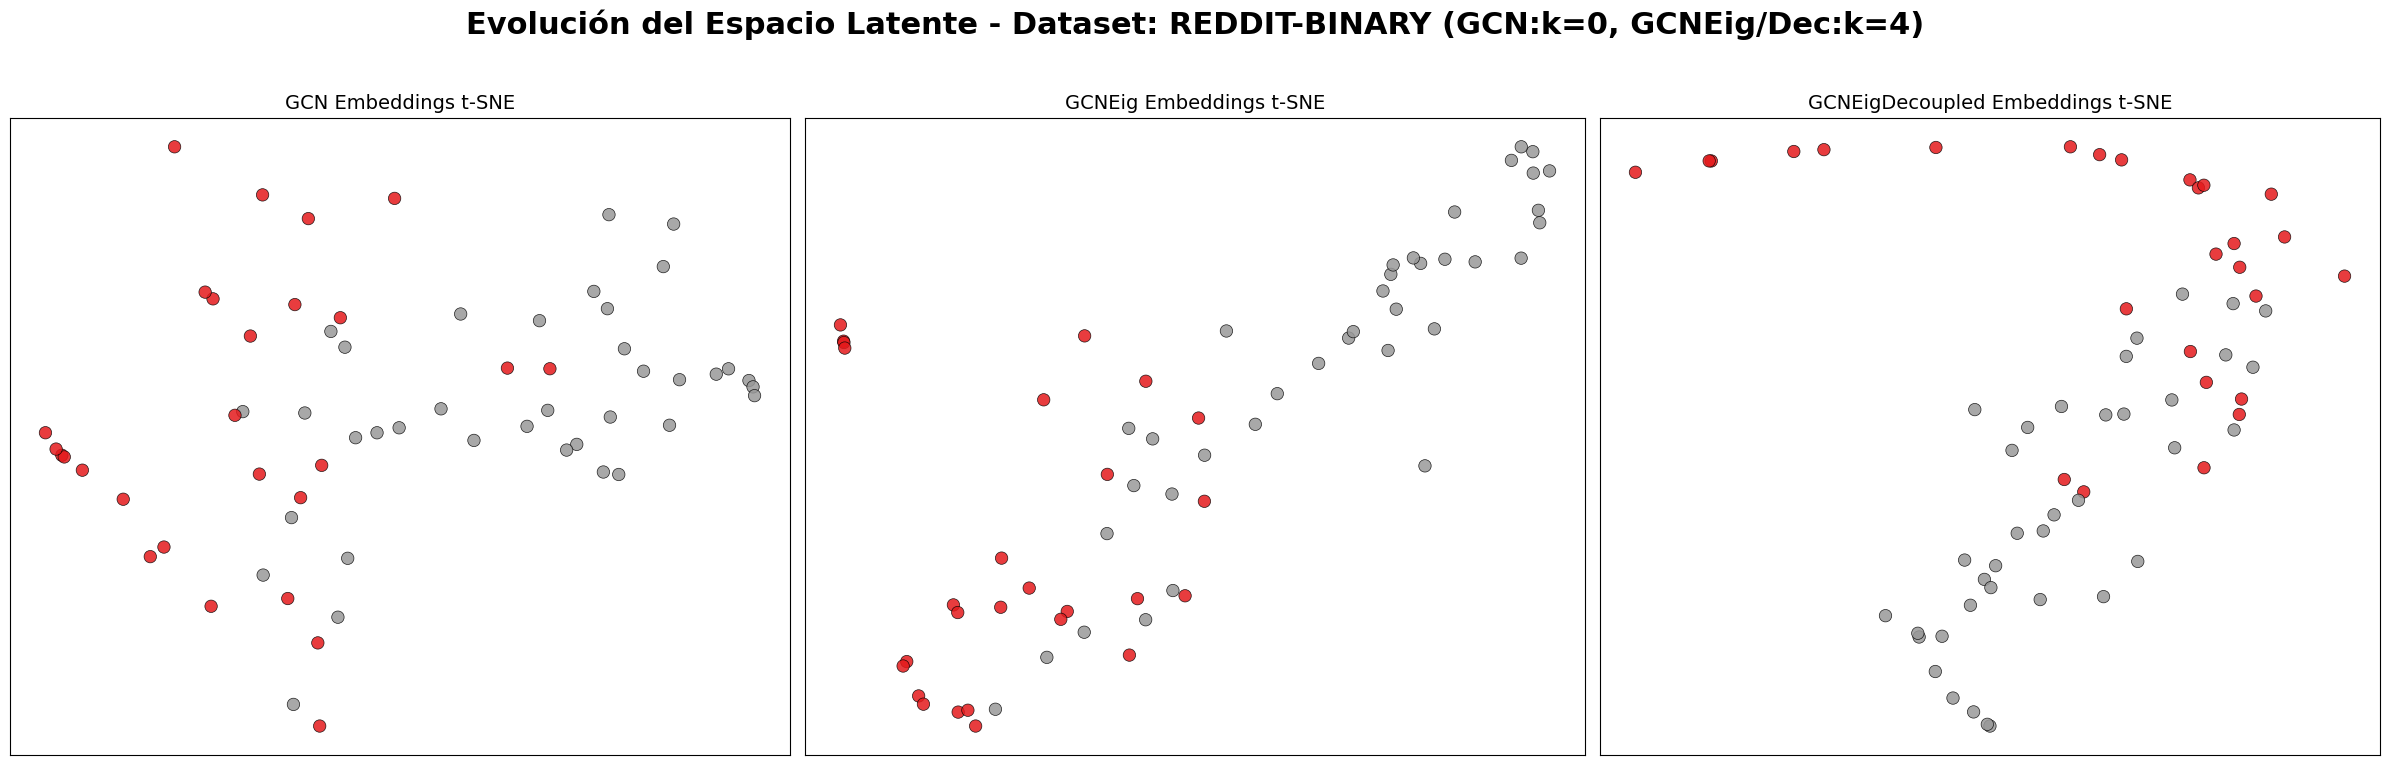

In [12]:
data_for_viz_batch = next(iter(test_loader)).to(device)
num_orig_features = dataset.num_node_features

# --- GCN Model (global_best_models[0][0]) ---
# This model was trained without Positional Encodings (k=0), so it expects 5 features.
best_gcn_model = global_best_models[0][0]
data_gcn_x = data_for_viz_batch.x[:, :num_orig_features] # Take only the original 5 features
out_gcn_embeddings = best_gcn_model.get_embeddings(data_gcn_x, data_for_viz_batch.edge_index, data_for_viz_batch.batch)

# --- Prepare data for GCNEig and GCNEigDecoupled (trained with k=4) ---
k_for_eig_models = 4 # These models were trained with k=4 in Experiment 4

evecs_list_k4 = []
for single_graph in data_for_viz_batch.to_data_list():
    evecs_single_k4 = compute_laplacian_eigenvectors_pytorch(single_graph, k=k_for_eig_models)
    # Pad with zeros if less than k_for_eig_models eigenvectors were found
    if evecs_single_k4.size(1) < k_for_eig_models:
        columnas_faltantes = k_for_eig_models - evecs_single_k4.size(1)
        evecs_single_k4 = F.pad(evecs_single_k4, (0, columnas_faltantes, 0, 0), "constant", 0.0)
    evecs_list_k4.append(evecs_single_k4)

# Concatenate eigenvectors for the entire batch, ensuring correct shape
evecs_for_eig_k4 = torch.cat(evecs_list_k4, dim=0).to(device)

# Create x with original 5 features + k=4 positional encodings
x_for_eig_k4 = torch.cat([data_for_viz_batch.x[:, :num_orig_features], evecs_for_eig_k4], dim=1)

# --- GCNEig Model (global_best_models[1][0]) ---
best_gcn_eig_model = global_best_models[1][0]
out_gcn_eig_embeddings = best_gcn_eig_model.get_embeddings(x_for_eig_k4, data_for_viz_batch.edge_index, data_for_viz_batch.batch)

# --- GCNEigDecoupled Model (global_best_models[2][0]) ---
best_gcn_eig_decoupled_model = global_best_models[2][0]
out_gcn_eig_decoupled_embeddings = best_gcn_eig_decoupled_model.get_embeddings(x_for_eig_k4, data_for_viz_batch.edge_index, data_for_viz_batch.batch)


# TSNE Transformation
tsne = TSNE(n_components=2, random_state=12345, init='pca', learning_rate='auto')

tsne_gcn = tsne.fit_transform(out_gcn_embeddings.detach().cpu().numpy())
tsne_gcn_eig = tsne.fit_transform(out_gcn_eig_embeddings.detach().cpu().numpy())
tsne_gcn_decoupled = tsne.fit_transform(out_gcn_eig_decoupled_embeddings.detach().cpu().numpy())

fig, axs = plt.subplots(1, 3, figsize=(24, 8))

# GCN
axs[0].set_title('GCN Embeddings t-SNE', fontsize=14)
scatter0 = axs[0].scatter(tsne_gcn[:,0], tsne_gcn[:,1], c=data_for_viz_batch.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

# GCNEig
axs[1].set_title('GCNEig Embeddings t-SNE', fontsize=14)
axs[1].scatter(tsne_gcn_eig[:,0], tsne_gcn_eig[:,1], c=data_for_viz_batch.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

# GCNEigDecoupled
axs[2].set_title('GCNEigDecoupled Embeddings t-SNE', fontsize=14)
axs[2].scatter(tsne_gcn_decoupled[:,0], tsne_gcn_decoupled[:,1], c=data_for_viz_batch.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'Evolución del Espacio Latente - Dataset: REDDIT-BINARY (GCN:k=0, GCNEig/Dec:k=4)', fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.show()

Al ser un problema de clasificación binaria, buscamos observar una polarización clara entre los puntos rojos y grises. De la proyección podemos extraer la siguiente información:

* **`GCN` (Izquierda):** Se observa una estructura dispersa y carente de un patrón claro. Aunque el modelo logra agrupar ligeramente algunos puntos, la gran mayoría de las redes están mezcladas caóticamente en la región central y derecha.
* **`GCNEig` (Centro):** El espacio latente sufre una transformación radical, organizándose en una clara banda o trayectoria diagonal. Comienza a apreciarse una segregación real: los puntos rojos tienden a agruparse en la parte inferior izquierda, mientras que los grises dominan la sección superior derecha. Añadir la topología del grafo permite a la red estructurar el espacio latente con mucha más lógica.
* **`GCNEigDecoupled` (Derecha):** Muestra una representación aún más estructurada y limpia siguiendo la misma distribución diagonal. Las clases están notablemente mejor ordenadas: los puntos rojos se polarizan de forma muy densa en la parte superior y el extremo derecho, mientras que los grises se concentran de forma compacta en la zona central e inferior izquierda. Procesar las características locales y la geometría global en vías separadas pule las fronteras de decisión y facilita enormemente la clasificación final.

### Conclusión final

El modelo ganador absoluto en este conjunto de datos es el **`GCNEig` con 64 canales, 4 capas, `Mean Pool` y $k=8$**, logrando una precisión en validación del **83.38%**, seguido muy de cerca por la arquitectura `GCNEigDecoupled` (**83.14%** con $k=6$).

La tesis de referencia no proporciona resultados para este conjunto de datos, por lo que no podemos comparar nuestros resultados de manera directa. No obstante, el fracaso del modelo `Net`, que colapsó al 63.60% al enfrentarse a este volumen de datos, pone de manifiesto la robustez, escalabilidad y potencia predictiva de nuestras arquitecturas.